# Causality with a DAG only : structural analysis without a BayesNet

| | | |
|-|-|-|
|[ ![Creative Commons License](images/cc4.png)](http://creativecommons.org/licenses/by-nc/4.0/) |[ ![aGrUM](images/logoAgrum.png)](https://pyagrum.gitlab.io) |[ ![interactive online version](images/atbinder.svg)](https://mybinder.org/v2/gl/agrumery%2FaGrUM/forBinder?urlpath=%2Fdoc%2Ftree%2Fwrappers%2Fpyagrum%2Fdoc%2Fsphinx%2Fnotebooks%2F67-Causality_CausalityWithDAGonly.ipynb)

A `CausalModel` is usually built from a `BayesNet` : the model then carries the observational CPTs needed to evaluate causal effects numerically. But almost everything a `CausalModel` does -- backdoor/frontdoor search, d-separation, `toDot`, induced sub-models, do-calculus identification -- only ever touches the **structure** of the causal DAG, never a probability table.

This notebook shows the other constructor : building a `CausalModel` directly from a plain named `gum.DAG`, with no `BayesNet` at all. Every structural operation keeps working; only the operations that genuinely need a probability distribution (`observationalBN()`, `variable()`, evaluating a `CausalImpact`, `counterfactual()`) raise `gum.OperationNotAllowed`.

In [1]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb

## Building a `CausalModel` from a plain DAG

hasObservationalBN() = False


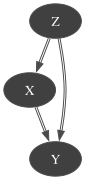

In [2]:
# Z is an observed confounder of X and Y
dag = gum.fastDAG("Z->X->Y;Z->Y")

cm = gum.CausalModel(dag)

print(f"hasObservationalBN() = {cm.hasObservationalBN()}")
gnb.showCausalModel(cm)

## Structural queries work without any CPT

Backdoor/frontdoor search, `existsArc`, `parents`, `children` and `connectedComponents` are all pure graph algorithms on the causal DAG : they never look at a probability table, so they work identically whether `cm` was built from a `BayesNet` or from a plain DAG.

In [3]:
print("backDoor(X, Y)  :", cm.backDoor("X", "Y"))
print("parents(Y)      :", cm.parents("Y"))
print("children(Z)     :", cm.children("Z"))
print("connected components:", cm.connectedComponentsList())

backDoor(X, Y)  : {0}
parents(Y)      : {0, 1}
children(Z)     : {1, 2}
connected components: {0: {0, 1, 2}}


Do-calculus identification (`gum.causalImpact`) builds the same way : it only needs the causal DAG to find an adjustment formula. Here, `Z` is found as a valid backdoor adjustment set for the effect of `X` on `Y`, and the identified `CausalImpact` object is returned -- but its `.eval()` cannot produce a numeric answer without CPTs (see below).

In [4]:
# Build the CausalImpact object directly (structural identification only,
# no evaluation yet) rather than via gum.causalImpact(), which would eagerly
# try to evaluate the numeric result.
ci = gum.CausalImpact(cm, on="Y", doing="X")
print(f"isIdentified() = {ci.isIdentified()}")
print(f"explanation    = {ci.explanation()}")
print(ci.toLatex())

isIdentified() = True
explanation    = backdoor ['Z'] found.
P\left(Y \mid \text{do}(X)\right) = \sum_{Z}{P\left(Y\mid X,Z\right) \cdot P\left(Z\right)}


## What raises `OperationNotAllowed`

Anything that needs an actual conditional probability table has no way to work on a DAG-only model, and raises `gum.OperationNotAllowed` instead of silently returning a wrong answer.

In [5]:
for label, thunk in [
  ("cm.observationalBN()", lambda: cm.observationalBN()),
  ("cm.variable('X')", lambda: cm.variable("X")),
  ("ci.eval()", lambda: ci.eval()),
]:
  try:
    thunk()
    print(f"{label}: no exception raised (unexpected)")
  except gum.OperationNotAllowed as e:
    print(f"{label}: raised OperationNotAllowed as expected")

cm.observationalBN(): raised OperationNotAllowed as expected
cm.variable('X'): raised OperationNotAllowed as expected
ci.eval(): raised OperationNotAllowed as expected


## Adding latents, and round-tripping through `causalDAG()`

Latent confounders are added the same way as for a `BayesNet`-based model. And since `causalDAG()` returns a fully named `DAG`, `CausalModel(cm.causalDAG())` is always a valid round-trip -- observed and latent nodes alike become plain observed nodes of the new model.

In [6]:
dag2 = gum.fastDAG("A->B->C")
cm2 = gum.CausalModel(dag2, [("U", ["A", "C"])])
print("latents:", cm2.latentVariablesNames())
print("A->C removed by latent surgery:", not cm2.existsArc("A", "C"))

cm3 = gum.CausalModel(cm2.causalDAG())
print(f"cm3.hasObservationalBN() = {cm3.hasObservationalBN()}")
print(f"cm3.existsArc('U','A') = {cm3.existsArc('U', 'A')}")

latents: {'U'}
A->C removed by latent surgery: True
cm3.hasObservationalBN() = False
cm3.existsArc('U','A') = True
